# LASSO Robustness Check: EUR/USD First Differences

This notebook evaluates whether the LASSO variable-selection results are sensitive to the transformation used to represent EUR/USD movements.

The analysis repeats the LASSO procedure using the **daily first difference of EUR/USD spot (`DEXUSEU_diff`)** as the target rather than EUR/USD log returns.

The candidate predictor set contains the macroeconomic controls together with all geopolitical representations considered in the VAR-X analysis:

- daily SUM geopolitical indices,
- daily MAX geopolitical indices,
- 3-day moving averages of the daily SUM indices,
- 5-day moving averages of the daily SUM indices,
- 10-day moving averages of the daily SUM indices.

LASSO regularisation is estimated using time-series cross-validation, allowing the robustness of the variable-selection results to the EUR/USD transformation to be assessed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV, lasso_path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
raw_path = Path("../../data/raw")
processed_path = Path("../../data/processed")

print("Raw path:", raw_path.resolve())
print("Processed path:", processed_path.resolve())

Raw path: C:\Users\franc\OneDrive\Geop-Model\data\raw
Processed path: C:\Users\franc\OneDrive\Geop-Model\data\processed


In [3]:
dexuseu = pd.read_csv(raw_path / "DEXUSEU.csv")

sum_df = pd.read_csv(processed_path / "macro_geopolitical_sum.csv")
max_df = pd.read_csv(processed_path / "macro_geopolitical_max.csv")
ma3_df = pd.read_csv(processed_path / "macro_geopolitical_ma3.csv")
ma5_df = pd.read_csv(processed_path / "macro_geopolitical_ma5.csv")
ma10_df = pd.read_csv(processed_path / "macro_geopolitical_ma10.csv")

In [4]:
dexuseu["observation_date"] = pd.to_datetime(dexuseu["observation_date"])

for df in [sum_df, max_df, ma3_df, ma5_df, ma10_df]:
    df["observation_date"] = pd.to_datetime(df["observation_date"])

In [5]:
for name, df in {
    "SUM": sum_df,
    "MAX": max_df,
    "MA3": ma3_df,
    "MA5": ma5_df,
    "MA10": ma10_df
}.items():
    print(
        name,
        df.shape,
        df["observation_date"].min(),
        df["observation_date"].max()
    )

SUM (993, 8) 2017-01-10 00:00:00 2021-01-08 00:00:00
MAX (993, 8) 2017-01-10 00:00:00 2021-01-08 00:00:00
MA3 (993, 8) 2017-01-10 00:00:00 2021-01-08 00:00:00
MA5 (993, 8) 2017-01-10 00:00:00 2021-01-08 00:00:00
MA10 (993, 8) 2017-01-10 00:00:00 2021-01-08 00:00:00


## 1. Construction of the First-Difference Target

The raw EUR/USD spot series is ordered chronologically and converted into daily first differences.

The resulting `DEXUSEU_diff` series is checked for missing observations and aligned with the geopolitical modelling sample over the common 2017–2021 period.

In [6]:
dexuseu_clean = (
    dexuseu
    .dropna(subset=["DEXUSEU"])
    .sort_values("observation_date")
    .copy()
)

dexuseu_clean["DEXUSEU_diff"] = (
    dexuseu_clean["DEXUSEU"].diff()
)

In [7]:
print(dexuseu_clean[
    ["observation_date", "DEXUSEU", "DEXUSEU_diff"]
].head(10))

print("\nMissing DEXUSEU levels:",
      dexuseu_clean["DEXUSEU"].isna().sum())

print("Missing DEXUSEU differences:",
      dexuseu_clean["DEXUSEU_diff"].isna().sum())

   observation_date  DEXUSEU  DEXUSEU_diff
0        2017-01-03   1.0416           NaN
1        2017-01-04   1.0476        0.0060
2        2017-01-05   1.0598        0.0122
3        2017-01-06   1.0560       -0.0038
4        2017-01-09   1.0576        0.0016
5        2017-01-10   1.0572       -0.0004
6        2017-01-11   1.0501       -0.0071
7        2017-01-12   1.0666        0.0165
8        2017-01-13   1.0625       -0.0041
10       2017-01-17   1.0695        0.0070

Missing DEXUSEU levels: 0
Missing DEXUSEU differences: 1


In [8]:
date_check = sum_df[
    ["observation_date"]
].merge(
    dexuseu_clean[
        ["observation_date", "DEXUSEU_diff"]
    ],
    on="observation_date",
    how="left"
)

print("Rows:", len(date_check))
print("Missing DEXUSEU_diff:", date_check["DEXUSEU_diff"].isna().sum())

print("\nDate range:")
print(
    date_check["observation_date"].min(),
    "to",
    date_check["observation_date"].max()
)

Rows: 993
Missing DEXUSEU_diff: 0

Date range:
2017-01-10 00:00:00 to 2021-01-08 00:00:00


## 1. Construction of the First-Difference Target

The raw EUR/USD spot series is ordered chronologically and converted into daily first differences.

The resulting `DEXUSEU_diff` series is checked for missing observations and aligned with the geopolitical modelling sample over the common 2017–2021 period.

In [9]:
lasso_diff_df = (
    sum_df
    .drop(columns=["DEXUSEU_logreturn"])
    .merge(
        dexuseu_clean[["observation_date", "DEXUSEU_diff"]],
        on="observation_date",
        how="left"
    )
)

In [10]:
lasso_diff_df = (
    lasso_diff_df
    .merge(
        max_df[[
            "observation_date",
            "trade_max",
            "sanctions_max",
            "fed_pressure_max"
        ]],
        on="observation_date",
        how="left"
    )
    .merge(
        ma3_df[[
            "observation_date",
            "trade_sum_ma3",
            "sanctions_sum_ma3",
            "fed_pressure_sum_ma3"
        ]],
        on="observation_date",
        how="left"
    )
    .merge(
        ma5_df[[
            "observation_date",
            "trade_sum_ma5",
            "sanctions_sum_ma5",
            "fed_pressure_sum_ma5"
        ]],
        on="observation_date",
        how="left"
    )
    .merge(
        ma10_df[[
            "observation_date",
            "trade_sum_ma10",
            "sanctions_sum_ma10",
            "fed_pressure_sum_ma10"
        ]],
        on="observation_date",
        how="left"
    )
)

In [11]:
lasso_diff_df = lasso_diff_df[[
    "observation_date",
    "DEXUSEU_diff",
    "DGS2_diff",
    "USEPUINDXD_diff",
    "VIXCLS",
    "trade_sum",
    "sanctions_sum",
    "fed_pressure_sum",
    "trade_max",
    "sanctions_max",
    "fed_pressure_max",
    "trade_sum_ma3",
    "sanctions_sum_ma3",
    "fed_pressure_sum_ma3",
    "trade_sum_ma5",
    "sanctions_sum_ma5",
    "fed_pressure_sum_ma5",
    "trade_sum_ma10",
    "sanctions_sum_ma10",
    "fed_pressure_sum_ma10"
]]

In [12]:
print("Shape:", lasso_diff_df.shape)

print("\nColumns:")
print(lasso_diff_df.columns.tolist())

print("\nMissing values:")
print(lasso_diff_df.isna().sum())

print("\nDuplicate dates:",
      lasso_diff_df["observation_date"].duplicated().sum())

print("\nDate range:")
print(
    lasso_diff_df["observation_date"].min(),
    "to",
    lasso_diff_df["observation_date"].max()
)

Shape: (993, 20)

Columns:
['observation_date', 'DEXUSEU_diff', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_sum', 'sanctions_sum', 'fed_pressure_sum', 'trade_max', 'sanctions_max', 'fed_pressure_max', 'trade_sum_ma3', 'sanctions_sum_ma3', 'fed_pressure_sum_ma3', 'trade_sum_ma5', 'sanctions_sum_ma5', 'fed_pressure_sum_ma5', 'trade_sum_ma10', 'sanctions_sum_ma10', 'fed_pressure_sum_ma10']

Missing values:
observation_date         0
DEXUSEU_diff             0
DGS2_diff                0
USEPUINDXD_diff          0
VIXCLS                   0
trade_sum                0
sanctions_sum            0
fed_pressure_sum         0
trade_max                0
sanctions_max            0
fed_pressure_max         0
trade_sum_ma3            0
sanctions_sum_ma3        0
fed_pressure_sum_ma3     0
trade_sum_ma5            0
sanctions_sum_ma5        0
fed_pressure_sum_ma5     0
trade_sum_ma10           0
sanctions_sum_ma10       0
fed_pressure_sum_ma10    0
dtype: int64

Duplicate dates: 0

Date range:
20

## 3. Target, Predictors and Train-Test Split

The daily first difference of EUR/USD is defined as the target variable. The remaining macroeconomic and geopolitical variables form the candidate predictor set.

The observations are split chronologically, with the first 80% used for model estimation and the final 20% reserved for out-of-sample evaluation.

This produces 794 training observations and 199 test observations. Predictor standardisation is fitted using the training sample only and subsequently applied to the test sample to avoid information leakage.

In [13]:
# Target: daily EUR/USD first difference
y = lasso_diff_df["DEXUSEU_diff"]

# Predictors: all macro + geopolitical variables
X = lasso_diff_df.drop(
    columns=["observation_date", "DEXUSEU_diff"]
)

print("Target:", y.name)
print("Number of predictors:", X.shape[1])
print("\nPredictors:")
print(X.columns.tolist())

Target: DEXUSEU_diff
Number of predictors: 18

Predictors:
['DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS', 'trade_sum', 'sanctions_sum', 'fed_pressure_sum', 'trade_max', 'sanctions_max', 'fed_pressure_max', 'trade_sum_ma3', 'sanctions_sum_ma3', 'fed_pressure_sum_ma3', 'trade_sum_ma5', 'sanctions_sum_ma5', 'fed_pressure_sum_ma5', 'trade_sum_ma10', 'sanctions_sum_ma10', 'fed_pressure_sum_ma10']


In [14]:
split = int(len(lasso_diff_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training period:")
print(
    lasso_diff_df["observation_date"].iloc[0],
    "to",
    lasso_diff_df["observation_date"].iloc[split - 1]
)

print("\nTest period:")
print(
    lasso_diff_df["observation_date"].iloc[split],
    "to",
    lasso_diff_df["observation_date"].iloc[-1]
)

print("\nTraining observations:", len(X_train))
print("Test observations:", len(X_test))

Training period:
2017-01-10 00:00:00 to 2020-03-20 00:00:00

Test period:
2020-03-23 00:00:00 to 2021-01-08 00:00:00

Training observations: 794
Test observations: 199


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (794, 18)
X_test_scaled shape: (199, 18)


## 4. LASSO Estimation and Cross-Validation

The LASSO penalty parameter is selected using five-fold time-series cross-validation.

`TimeSeriesSplit` preserves the chronological ordering of the observations rather than randomly shuffling the data, making the validation procedure appropriate for the time-series structure of the analysis.

The cross-validation-selected penalty determines which predictors retain non-zero coefficients in the optimally regularised model.

In [16]:
tscv = TimeSeriesSplit(n_splits=5)

lasso = LassoCV(
    cv=tscv,
    max_iter=100000
)

lasso.fit(X_train_scaled, y_train)

print("Selected alpha:", lasso.alpha_)
print("Number of non-zero coefficients:", np.sum(lasso.coef_ != 0))

Selected alpha: 0.0005300629987118776
Number of non-zero coefficients: 0


In [17]:
print("Largest alpha tested:", lasso.alphas_.max())
print("Smallest alpha tested:", lasso.alphas_.min())
print("Selected alpha:", lasso.alpha_)
print("Number of non-zero coefficients:", np.sum(lasso.coef_ != 0))

Largest alpha tested: 0.0005300629987118776
Smallest alpha tested: 5.300629987118777e-07
Selected alpha: 0.0005300629987118776
Number of non-zero coefficients: 0


In [18]:
coef_diff = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": lasso.coef_,
    "Absolute_Coefficient": np.abs(lasso.coef_)
}).sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coef_diff

,Variable,Coefficient,Absolute_Coefficient
0,DGS2_diff,0.0,0.0
1,USEPUINDXD_diff,0.0,0.0
2,VIXCLS,0.0,0.0
3,trade_sum,0.0,0.0
4,sanctions_sum,0.0,0.0
5,fed_pressure_sum,0.0,0.0
6,trade_max,0.0,0.0
7,sanctions_max,0.0,0.0
8,fed_pressure_max,0.0,0.0
9,trade_sum_ma3,0.0,0.0


## 5. Exploratory Regularisation Analysis

Because the cross-validation-selected penalty shrinks all 18 candidate coefficients to zero, weaker penalty values are examined to understand how variables enter the model as regularisation is relaxed.

This is an exploratory coefficient-path analysis rather than an alternative model-selection procedure. Variables appearing under weaker penalties are therefore not treated as predictors selected by the cross-validated LASSO model.

The exercise instead identifies which variables are the first to retain non-zero coefficients as the strength of regularisation decreases.

In [19]:
alphas_to_check = [
    lasso.alphas_[0],
    lasso.alphas_[20],
    lasso.alphas_[40],
    lasso.alphas_[60],
    lasso.alphas_[80],
    lasso.alphas_[-1]
]

for alpha in alphas_to_check:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_train_scaled, y_train)

    n_selected = np.sum(model.coef_ != 0)

    print(
        f"alpha = {alpha:.8f} | "
        f"selected variables = {n_selected}"
    )

alpha = 0.00053006 | selected variables = 0
alpha = 0.00013130 | selected variables = 6
alpha = 0.00003252 | selected variables = 15
alpha = 0.00000806 | selected variables = 16
alpha = 0.00000200 | selected variables = 17
alpha = 0.00000053 | selected variables = 17


In [20]:
alpha_6 = lasso.alphas_[20]

model_6 = Lasso(
    alpha=alpha_6,
    max_iter=100000
)

model_6.fit(X_train_scaled, y_train)

selected_6_diff = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model_6.coef_
})

selected_6_diff = selected_6_diff[
    selected_6_diff["Coefficient"] != 0
].copy()

selected_6_diff["Absolute_Coefficient"] = (
    selected_6_diff["Coefficient"].abs()
)

selected_6_diff = selected_6_diff.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

selected_6_diff

,Variable,Coefficient,Absolute_Coefficient
2,VIXCLS,-0.000505,0.000505
0,DGS2_diff,-0.000454,0.000454
16,sanctions_sum_ma10,-0.000190,0.000190
5,fed_pressure_sum,0.000085,0.000085
7,sanctions_max,-0.000052,0.000052
17,fed_pressure_sum_ma10,-0.000039,0.000039


## 6. Out-of-Sample Evaluation

The cross-validation-selected LASSO model is evaluated on the chronologically held-out test sample.

Forecast performance is assessed using root mean squared error (RMSE), mean absolute error (MAE), and the coefficient of determination (R²).

Because the optimal penalty shrinks all predictor coefficients to zero, the out-of-sample results provide an additional indication of whether the available macroeconomic and geopolitical variables contain robust linear predictive information for EUR/USD first differences under LASSO regularisation.

In [21]:
y_pred = lasso.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("LASSO Test RMSE:", rmse)
print("LASSO Test MAE:", mae)
print("LASSO Test R²:", r2)

LASSO Test RMSE: 0.0049201162257417694
LASSO Test MAE: 0.003886334063263422
LASSO Test R²: -0.025003202393894863


## 7. Regularisation Diagnostics

The cross-validation error curve and LASSO coefficient paths are examined to visualise the effect of the regularisation penalty.

The cross-validation plot shows the location of the selected penalty relative to the tested range, while the coefficient-path plot illustrates how individual predictors enter the model as the penalty is progressively reduced.

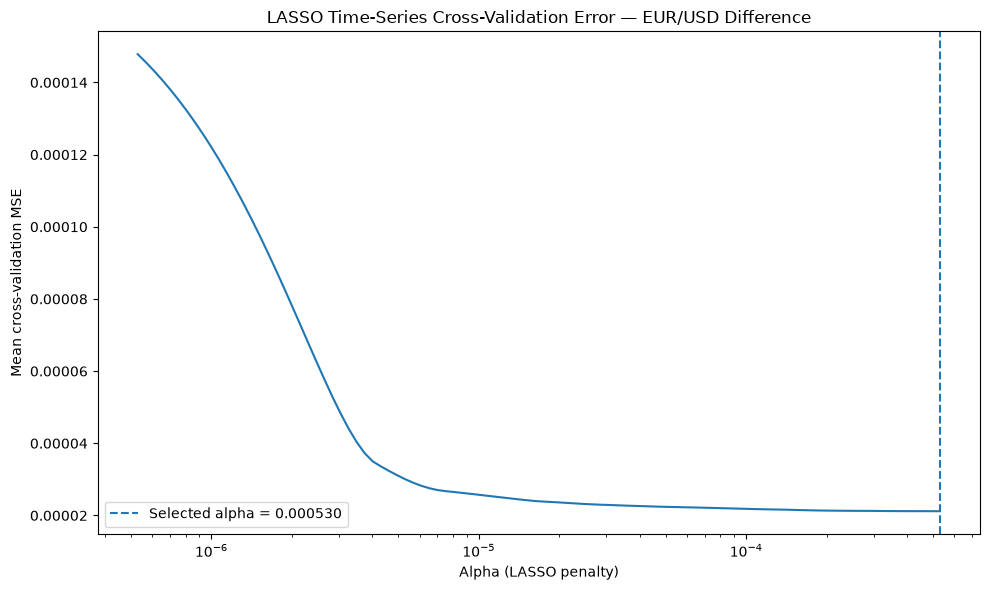

In [22]:
mse_mean = lasso.mse_path_.mean(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(lasso.alphas_, mse_mean)

plt.axvline(
    lasso.alpha_,
    linestyle="--",
    label=f"Selected alpha = {lasso.alpha_:.6f}"
)

plt.xscale("log")

plt.xlabel("Alpha (LASSO penalty)")
plt.ylabel("Mean cross-validation MSE")
plt.title("LASSO Time-Series Cross-Validation Error — EUR/USD Difference")

plt.legend()
plt.tight_layout()
plt.show()

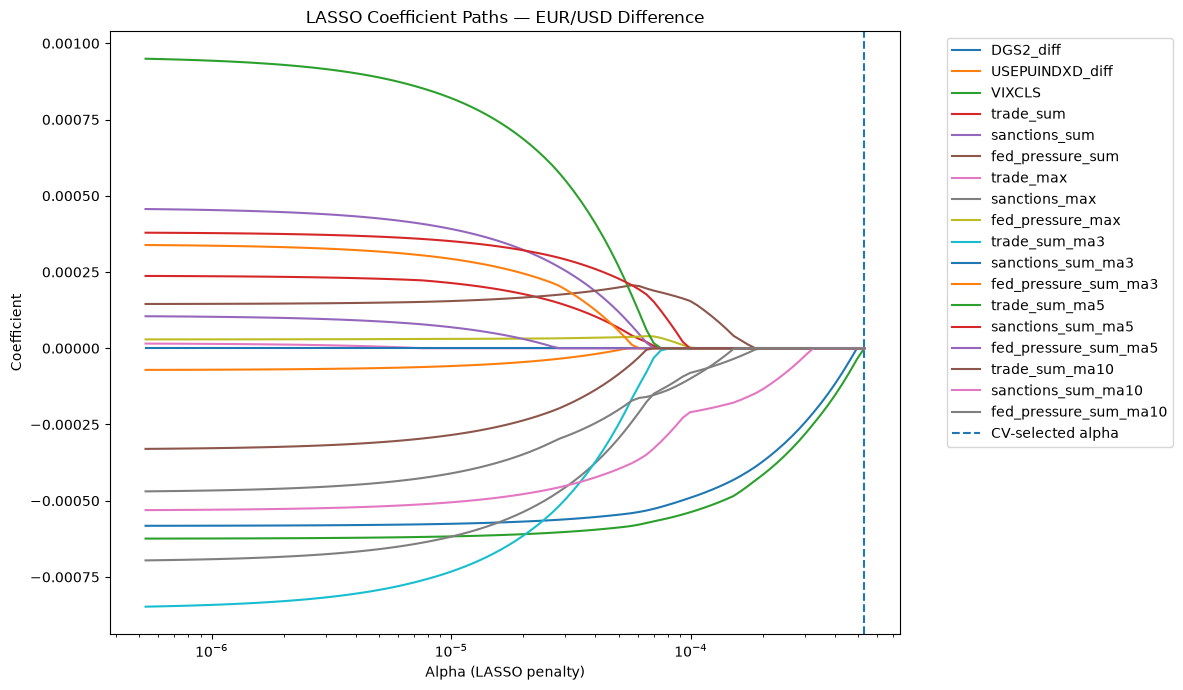

In [23]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled,
    y_train
)

plt.figure(figsize=(12, 7))

for i, variable in enumerate(X.columns):
    plt.plot(
        alphas_path,
        coefs_path[i],
        label=variable
    )

plt.axvline(
    lasso.alpha_,
    linestyle="--",
    label="CV-selected alpha"
)

plt.xscale("log")

plt.xlabel("Alpha (LASSO penalty)")
plt.ylabel("Coefficient")
plt.title("LASSO Coefficient Paths — EUR/USD Difference")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 8. Robustness Result

Replacing EUR/USD log returns with first differences produces essentially the same LASSO variable-selection result.

Time-series cross-validation selects the maximum tested penalty, shrinking all 18 candidate predictor coefficients to zero. Under weaker penalisation, six variables are the first to retain non-zero coefficients: VIX, the change in the US 2-Year Treasury yield, the 10-day moving average of Sanctions Threat, the daily summed Federal Reserve Pressure index, the daily maximum Sanctions Threat index, and the 10-day moving average of Federal Reserve Pressure.

Out-of-sample performance remains weak, with an RMSE of approximately **0.00492**, MAE of approximately **0.00389**, and R² of approximately **−0.025**.

The similarity between the log-return and first-difference specifications indicates that the main LASSO variable-selection result is robust to the transformation used to represent daily EUR/USD movements.